In [1]:
import numpy as np
import matplotlib.pyplot as plt
import zfit
import cmath
import math
import scipy

/home/fontes/prog/listas/.my_env/lib/python3.11/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
## LIFETIMES AND DECAY
k_s_tau = 8.958e-11
k_l_tau = 5.116e-8

gamma_s = 1/(k_s_tau)
gamma_l = 1/(k_l_tau)

delta_gamma = (gamma_s-gamma_l)*1e-9
print(delta_gamma)

delta_m = 5.293


## true epsilon

epsilon = cmath.rect(2.264e-3, math.radians(43.19))

11.143659552064792


In [5]:
# MIXING ASYMMETRY FOR NEUTRAL KAONS

def A_t(t):
    # epsilon: complex number |eps| e^{i phi}
    abs_e = abs(epsilon)
    phi   = cmath.phase(epsilon)      # phase in radians

    # avoid overflow for large t by using exp safely
    exp_half = np.exp(0.5 * delta_gamma * t)
    exp_full = np.exp(delta_gamma * t)

    numer = 2.0 * abs_e * exp_half * np.cos(delta_m * t - phi)
    denom = 1.0 + (abs_e**2) * exp_full

    return  -1* numer / denom

A_t_vec = np.vectorize(A_t)

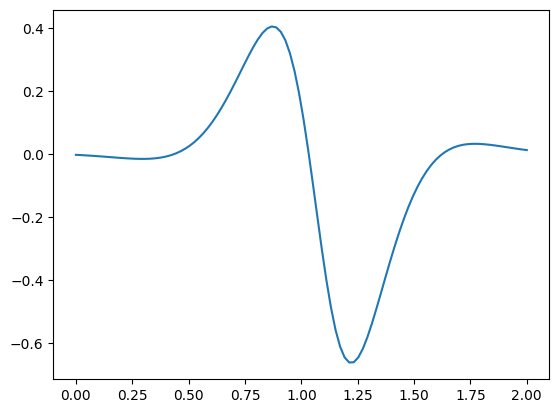

In [6]:
N = 100
tmax = 2
time_array = np.linspace(0, 2, N)
A_true  = A_t_vec(time_array)

plt.plot(time_array, A_true)

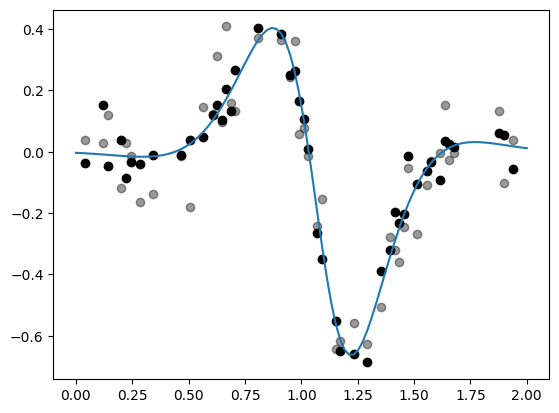

In [9]:
plt.plot(time_array, A_true)

time_event = time_array[np.random.uniform(0,1,N)>0.6]
sigma=0.05
noise = np.random.normal(0, sigma, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

plt.scatter(time_event, A_measured, c='black')


noise = np.random.normal(0, 0.1, size=time_event.size)
A_measured = A_t_vec(time_event) + noise

plt.scatter(time_event, A_measured, c='black', alpha=0.4)


In [11]:

## N_events = numero de eventos, select = % de eventos selecionados, 
def random_sampling_with_error(sigma, N_events=100, select=0.6):
    time_array_true = np.linspace(0, 2, N_events)
    
    mask = np.random.rand(N_events) < select
    time_event = time_array_true[mask]

    noise = np.random.normal(0, sigma, size=time_event.size)
    A_event = A_t_vec(time_event) + noise

    return time_event, A_event

def A_minimizer(t, abs_e, phi):

    # avoid overflow for large t by using exp safely
    exp_half = np.exp(0.5 * delta_gamma * t)
    exp_full = np.exp(delta_gamma * t)

    numer = 2.0 * abs_e * exp_half * np.cos(delta_m * t - phi)
    denom = 1.0 + (abs_e**2) * exp_full

    return  -1* numer / denom

def run_minimizer(sigma=0.02):    
    time_event, A_event = random_sampling_with_error(sigma)
    popt, pcov = scipy.optimize.curve_fit(A_minimizer, time_event, A_event, p0=[2e-3, np.radians(45)])
    return popt, np.diag(pcov)

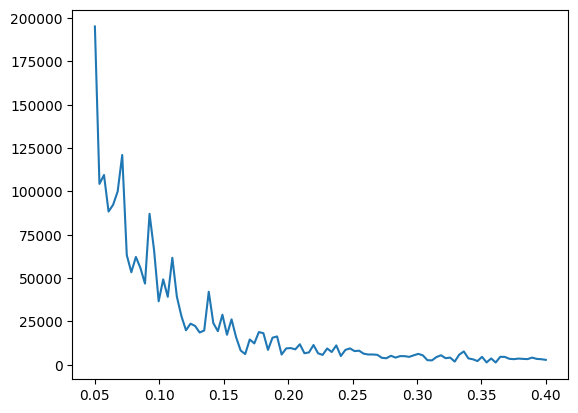

In [19]:
sigmas = np.linspace(0.05, 0.4, 100)
sig_vec = []
for sgm in sigmas:
    var_vals = []
    var_errs = []
    for i in range(100):
        popt, errs =  run_minimizer(sigma=sgm)
        var_vals.append(popt)
        var_errs.append(errs)
    significance = np.mean(np.abs(np.array(var_vals[0])) / np.array(var_errs[0]))
    sig_vec.append(significance)

plt.plot(sigmas, sig_vec)


In [59]:
def a(x, b, c):
    return (1+(b/(x+c)))

popt2,  pcov2 = scipy.optimize.curve_fit(a, sigmas, sig_vec, p0=[3000, 0.1])

array([ 2.58270524e+03, -3.54192353e-02])

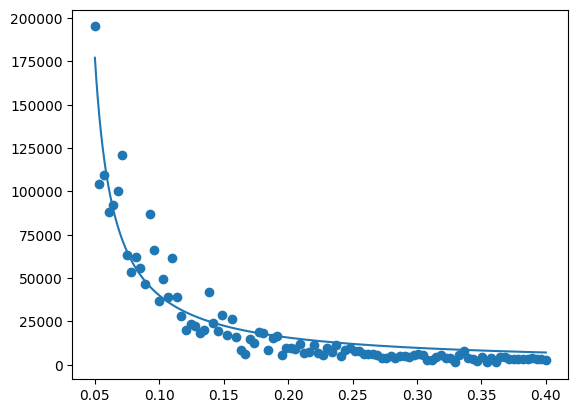

In [ ]:
sgm_lin = np.linspace(0.05,0.4, 1000)
plt.plot(sgm_lin, a(sgm_lin, *popt2))
plt.scatter(sigmas, sig_vec)
popt2

## a does not fit well 
